**STEP 1: Install Required Libraries**

In [1]:
!pip install -q openai-whisper
!pip install -q deep-translator
!pip install -q diffusers transformers accelerate safetensors
!pip install -q sentencepiece

**STEP 2: Import Libraries**

In [2]:
import torch
import whisper

from diffusers import StableDiffusionPipeline
from deep_translator import GoogleTranslator

from google.colab import files
from PIL import Image

print("Libraries Loaded")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Libraries Loaded


**STEP 3: Upload Audio File**

In [3]:
uploaded = files.upload()

audio_file = list(uploaded.keys())[0]

print("Uploaded File:", audio_file)

Saving tamil.mp3 to tamil (1).mp3
Uploaded File: tamil (1).mp3


**STEP 4: Convert Speech to Text**

In [4]:
model = whisper.load_model("large")

result = model.transcribe(audio_file)

speech_text = result["text"]

print("\nDetected Speech:")
print(speech_text)


Detected Speech:
 வணியால் மூடப்பட்ட மலைகளுக்கு நடுவே ஒரு மரக்குடில் உள்ளது.


**STEP 5: Translate to English**

In [5]:
english_prompt = GoogleTranslator(
    source='auto',
    target='en'
).translate(speech_text)

print("\nEnglish Prompt:")
print(english_prompt)


English Prompt:
There is a log cabin in the middle of the snow covered mountains.


**STEP 6: Improve Prompt**

In [6]:
enhanced_prompt = f"""
{english_prompt},
ultra realistic,
cinematic lighting,
8k quality,
highly detailed,
professional photography,
masterpiece
"""

print(enhanced_prompt)


There is a log cabin in the middle of the snow covered mountains.,
ultra realistic,
cinematic lighting,
8k quality,
highly detailed,
professional photography,
masterpiece



**STEP 7: Load Stable Diffusion**

In [7]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Model Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model Loaded


**STEP 8: Generate Image**

  0%|          | 0/30 [00:00<?, ?it/s]

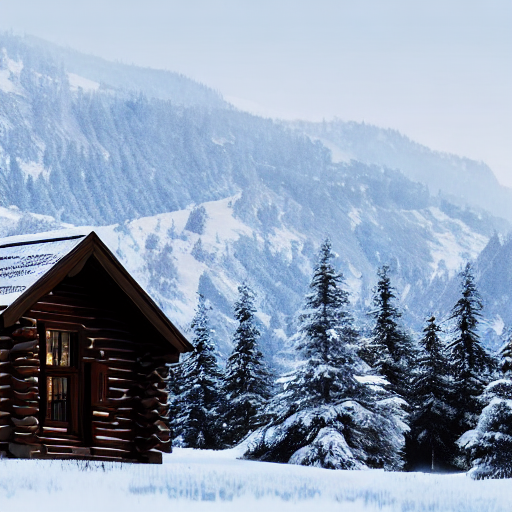

In [10]:
image = pipe(
    enhanced_prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

image.save("generated_image.png")

image

**STEP 9: Download Generated Image**

In [11]:
files.download("generated_image.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>